In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns

In [ ]:
model = tf.keras.models.load_model("/content/conv_model.h5")

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 524, 16)        │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv1D (Conv1D)                 │ (None, 520, 64)        │         5,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 260, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ TargetConv (Conv1D)             │ (None, 256, 128)       │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 11)             │         1,419 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 64,525 (252.05 KB)

 Trainable params: 64,523 (252.04 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [ ]:
from sklearn.preprocessing import LabelEncoder

def preprocess_input(seq):
  seq_ser = pd.Series([x for x in seq])
  amino_acids = sorted(list(set('ACDEFGHIKLMNPQRSTVWY')))
  aa_encoding = {aa: i for i, aa in enumerate(amino_acids)}
  seq_ser =  seq_ser.map(lambda x: aa_encoding.get(x, -1))
  seq_ser = np.array(seq_ser, dtype=np.int32).reshape(1, -1)
  return seq_ser

def find_peaks(arr, threshold_pct=200):
    mean_val = np.mean(arr)
    threshold = mean_val * (1 + threshold_pct / 100.0)
    peaks_idx = np.where(arr > threshold)[0]
    return peaks_idx

In [ ]:
def saliency_map(seq):
  input_sample = preprocess_input(seq)

  input_tensor = tf.convert_to_tensor(input_sample, dtype=tf.int32)

  embedding_layer = model.get_layer("embedding")


  embedded_input = embedding_layer(input_tensor)


  with tf.GradientTape() as tape:
      tape.watch(embedded_input)

      x = embedded_input
      for layer in model.layers[model.layers.index(embedding_layer)+1:]:
            x = layer(x)
      predictions = x

      predicted_class = tf.argmax(predictions[0])
      output = predictions[0, predicted_class]

  grads = tape.gradient(output, embedded_input)

  saliency = tf.reduce_max(tf.abs(grads), axis=-1).numpy()[0]

  print("The predicted host is " , np.argmax(model.predict(input_sample)))

  plt.figure(figsize=(15,3))
  plt.plot(saliency)
  plt.title(f"Saliency Map")
  plt.xlabel("Sequence Position for " + str(np.argmax(model.predict(input_sample))))
  plt.ylabel("Importance")
  plt.show()

  print(find_peaks(saliency))

0 - Bos Taurus <br>
1 - Canidae <br>
2 - Canis Lupis Familiaris <br>
3 - Eptesicus Fuscus <br>
4 - Felis Catus <br>
5 - Homo Sapiens <br>
6 - Melogale <br>
7 - Mephtidae <br>
8 - Procyon Lotor <br>
9 - Vulpes



##Analysing the Similarity in Residue Importance for Same Host

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
The predicted host is  2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


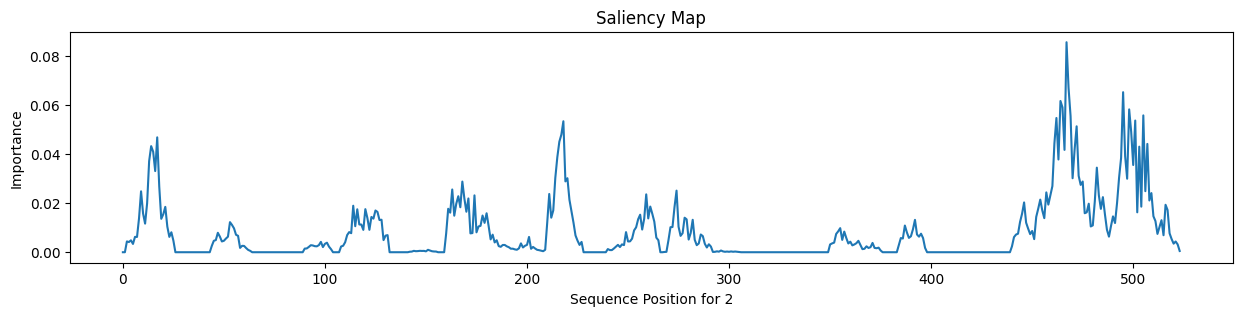

[  9  13  14  15  16  17  18 163 168 214 215 216 217 218 219 220 274 460
 461 462 463 464 465 466 467 468 469 470 471 472 473 474 475 482 493 494
 495 496 497 498 499 500 501 503 505 506 507]


In [ ]:
seq_canisfam1 = "MVPQTLLFVPLLVFPLCFGKFPIYTIPDKLGPWSPIDIHHLSCPNNLVVEDEGCTNLSGFSYMELKVGYISAIKVNGFTCTGVVTEAETYTNFVGYVTTTFKRKHFRPTPDACRAAYNWKMAGDPRYEESLHNPYPDYHWLRTVKTTKESLVIISPSVADLDPYDKSLHSRVFPSGKCSGITVSSTYCSTNHDYTIWMPENPRLGTSCDIFANSKGKRASKGSKTCGFVDERGLYKSLKGACKLKLCGVLGLRLMDGTWVAMQTSDETKWCPPDQLVNLHDFRSDEIEHLVVEELVKKREECLDALESIMTTKSVSFRRLSHLRKLVPGFGKAYTIFNKTLMEADAHYKSVRTWNEIIPSKGCLRVGGRCHPHVNGVFFNGIILGPDGHVLIPEMQSSLLQQHMELLESSVIPLMHPLADPSTVFKDGDEAEDFVEVHLPDVHKQVSGVDLGLPNWGKYVLLSAGTLIALMLIIFLMTCCRRVNRSGPTQRSLGGTGRKVSVTSQSGKVISSWESYKSGGETRL"
saliency_map(seq_canisfam1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
The predicted host is  2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


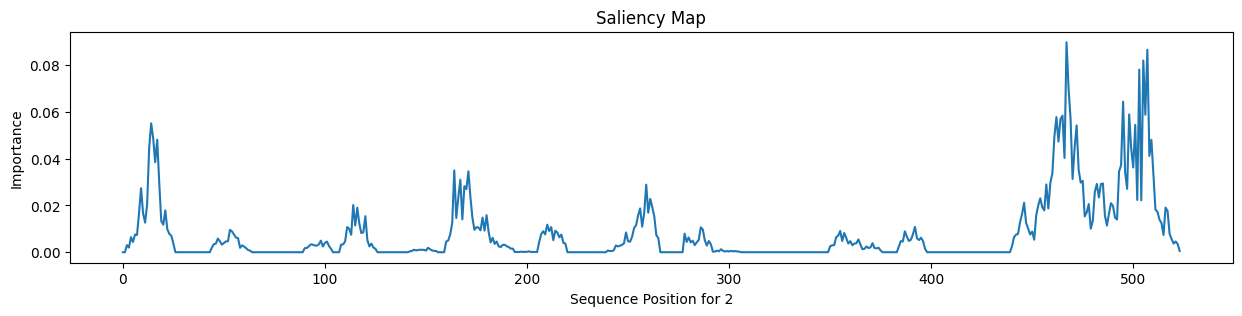

[  9  13  14  15  16  17  18 164 167 169 170 171 259 457 459 460 461 462
 463 464 465 466 467 468 469 470 471 472 473 474 475 481 482 484 485 493
 494 495 496 497 498 499 500 501 503 505 506 507 508 509 510]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
The predicted host is  2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step


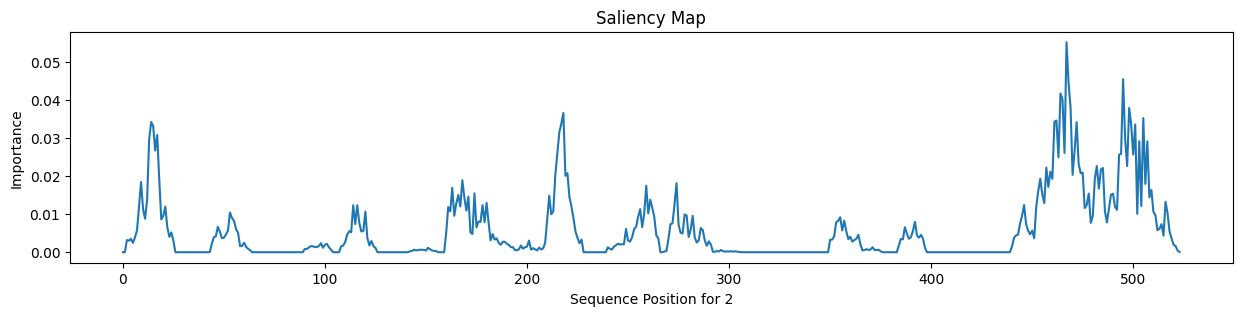

[  9  13  14  15  16  17  18 168 214 215 216 217 218 219 220 259 274 454
 457 459 460 461 462 463 464 465 466 467 468 469 470 471 472 473 474 475
 481 482 484 485 493 494 495 496 497 498 499 500 501 503 505 506 507]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
The predicted host is  2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


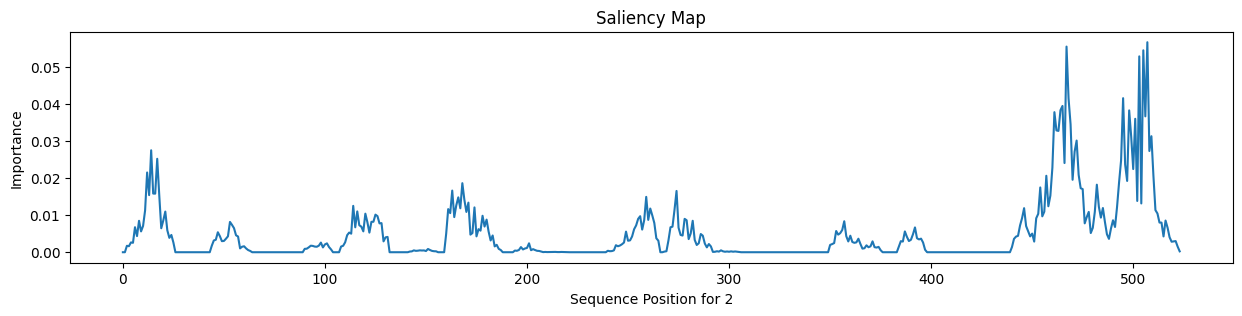

[ 12  13  14  15  16  17  18 163 166 168 259 274 454 457 459 460 461 462
 463 464 465 466 467 468 469 470 471 472 473 474 475 482 493 494 495 496
 497 498 499 500 501 503 505 506 507 508 509 510]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
The predicted host is  2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


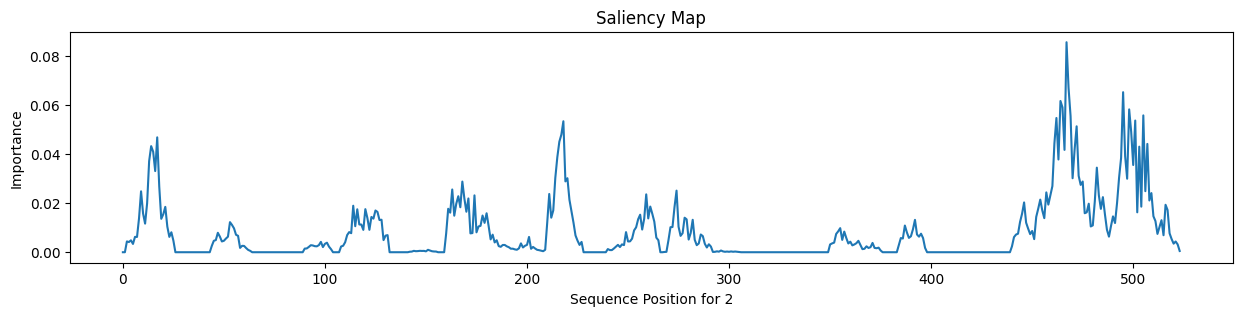

[  9  13  14  15  16  17  18 163 168 214 215 216 217 218 219 220 274 460
 461 462 463 464 465 466 467 468 469 470 471 472 473 474 475 482 493 494
 495 496 497 498 499 500 501 503 505 506 507]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
The predicted host is  2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


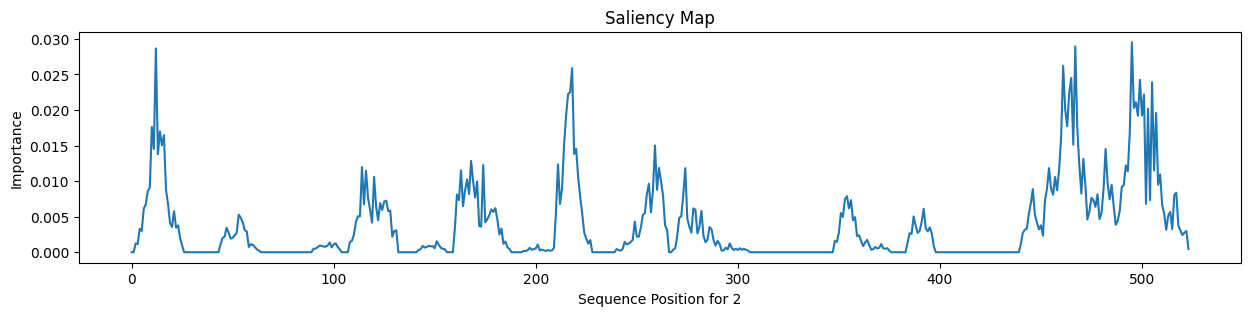

[ 10  11  12  13  14  15  16 114 116 163 168 174 211 214 215 216 217 218
 219 220 259 261 274 454 459 460 461 462 463 464 465 466 467 468 469 471
 482 492 493 494 495 496 497 498 499 500 501 503 505 506 507]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
The predicted host is  2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


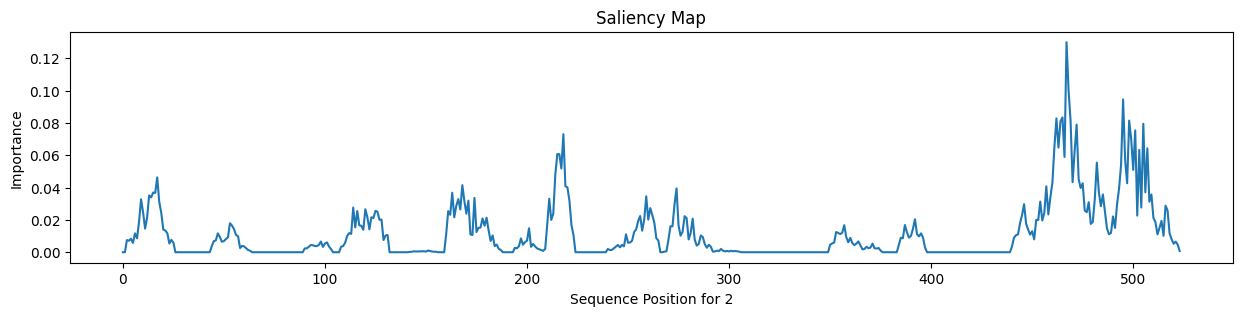

[ 15  16  17 163 168 214 215 216 217 218 219 220 274 457 460 461 462 463
 464 465 466 467 468 469 470 471 472 473 474 475 482 483 485 493 494 495
 496 497 498 499 500 501 503 505 506 507 509]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
The predicted host is  2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


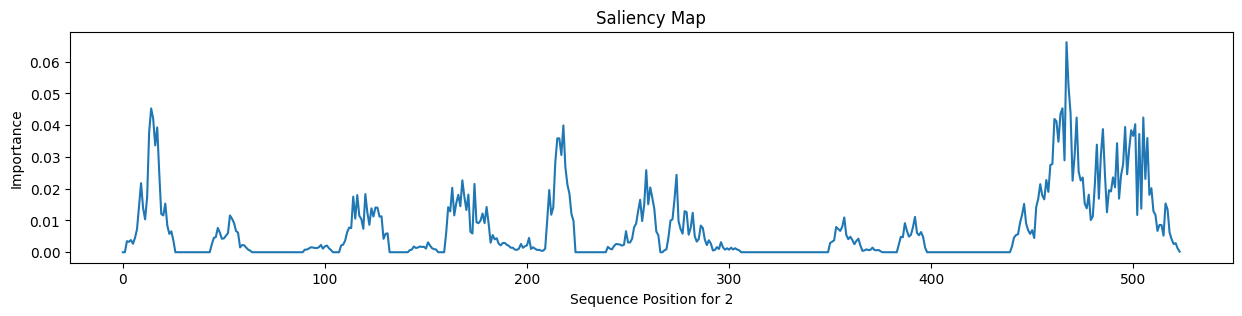

[  9  13  14  15  16  17  18 168 214 215 216 217 218 219 259 274 457 459
 460 461 462 463 464 465 466 467 468 469 470 471 472 473 474 475 482 484
 485 486 490 492 494 495 496 497 498 499 500 501 503 505 506 507]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
The predicted host is  2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


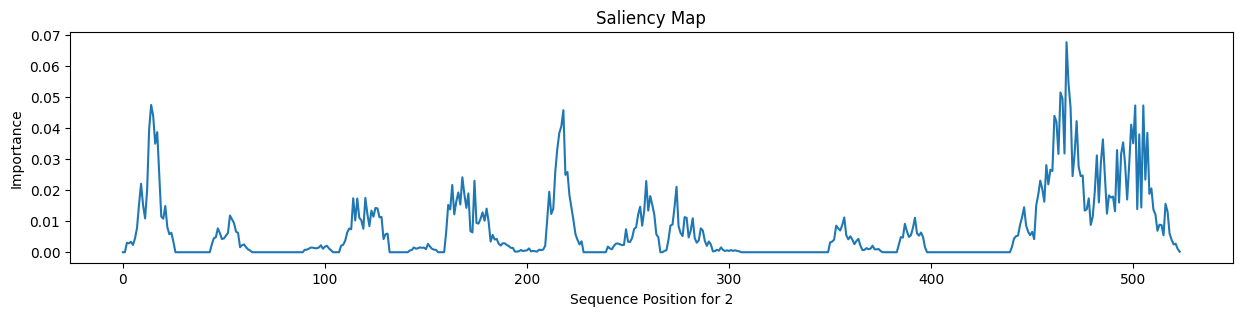

[  9  13  14  15  16  17  18 168 174 214 215 216 217 218 219 220 259 454
 457 458 459 460 461 462 463 464 465 466 467 468 469 470 471 472 473 474
 475 482 484 485 486 492 494 495 496 498 499 500 501 503 505 506 507]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
The predicted host is  2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


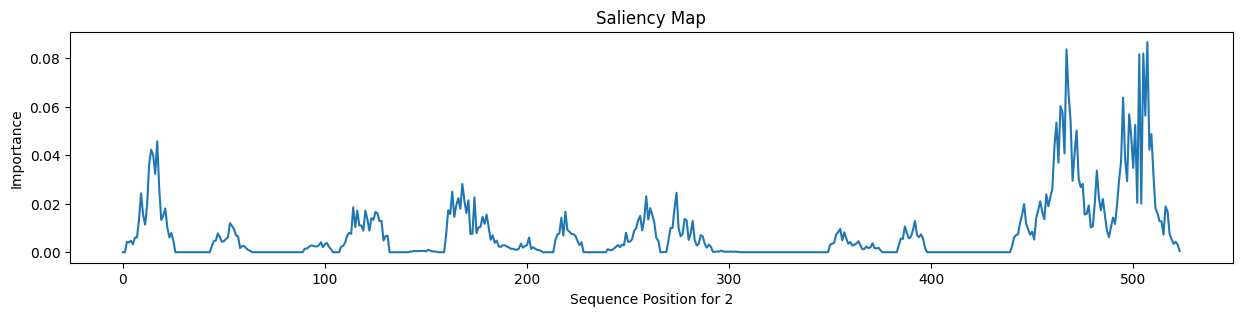

[  9  13  14  15  16  17  18 163 168 274 457 460 461 462 463 464 465 466
 467 468 469 470 471 472 473 474 475 482 493 494 495 496 497 498 499 500
 501 503 505 506 507 508 509 510]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
The predicted host is  2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


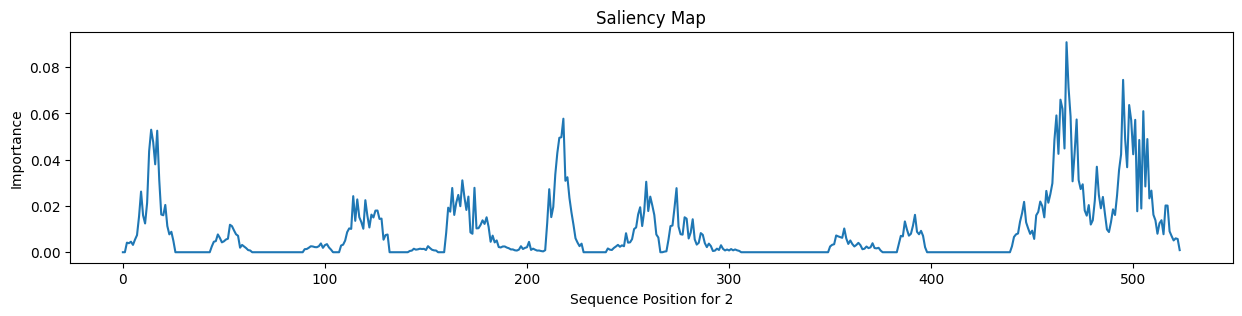

[ 13  14  15  16  17  18 163 168 174 214 215 216 217 218 219 220 259 274
 460 461 462 463 464 465 466 467 468 469 470 471 472 473 474 475 482 493
 494 495 496 497 498 499 500 501 503 505 506 507]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
The predicted host is  2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


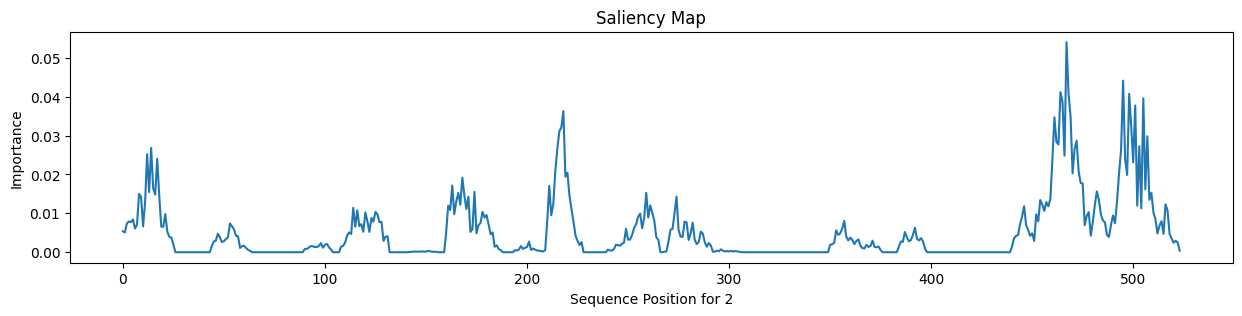

[ 12  14  15  17 163 168 211 214 215 216 217 218 219 220 460 461 462 463
 464 465 466 467 468 469 470 471 472 473 474 475 493 494 495 496 497 498
 499 500 501 503 505 506 507]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
The predicted host is  2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step


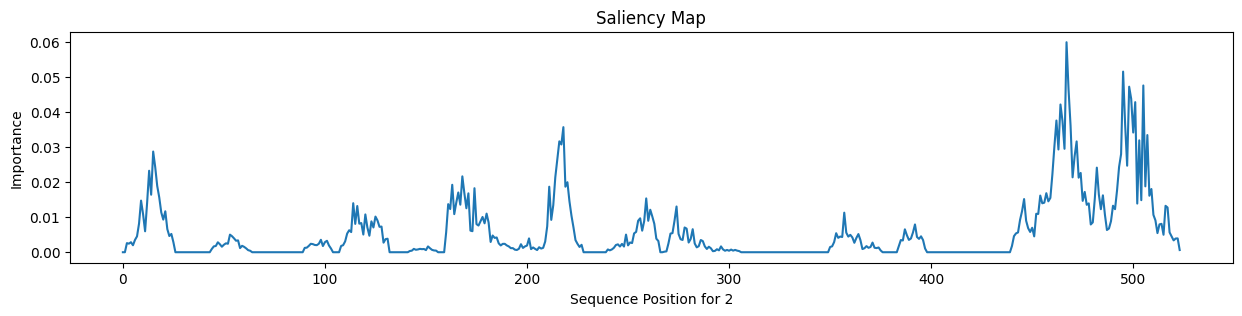

[ 13  15  16  17 163 168 174 211 214 215 216 217 218 219 220 460 461 462
 463 464 465 466 467 468 469 470 471 472 473 474 482 492 493 494 495 496
 497 498 499 500 501 503 505 506 507 509]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
The predicted host is  2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


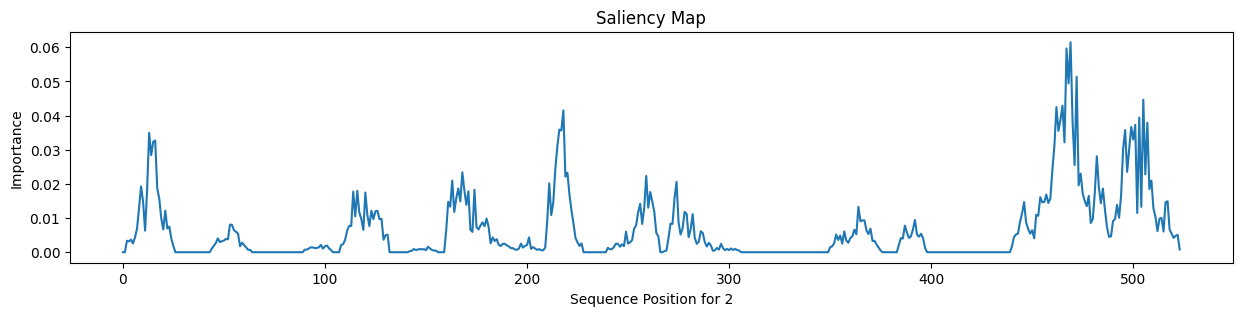

[ 13  14  15  16 163 168 211 214 215 216 217 218 219 220 259 274 460 461
 462 463 464 465 466 467 468 469 470 471 472 473 474 482 495 496 497 498
 499 500 501 503 505 506 507 509]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
The predicted host is  2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step


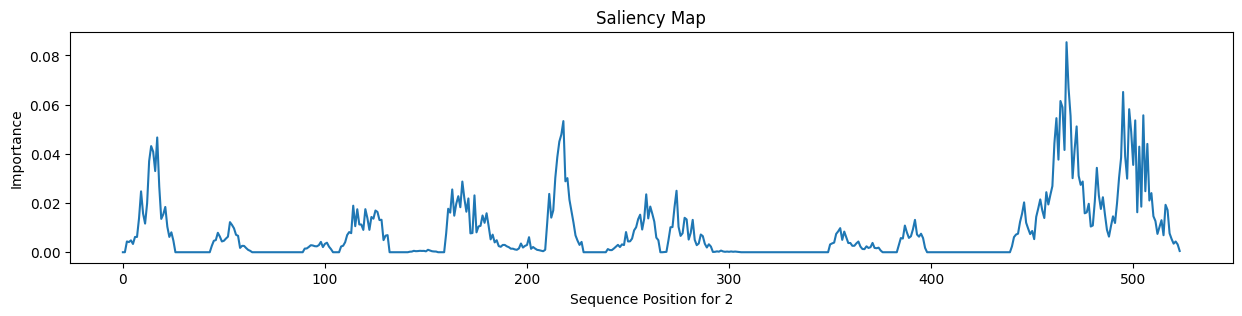

[  9  13  14  15  16  17  18 163 168 214 215 216 217 218 219 220 274 460
 461 462 463 464 465 466 467 468 469 470 471 472 473 474 475 482 493 494
 495 496 497 498 499 500 501 503 505 506 507]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
The predicted host is  2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


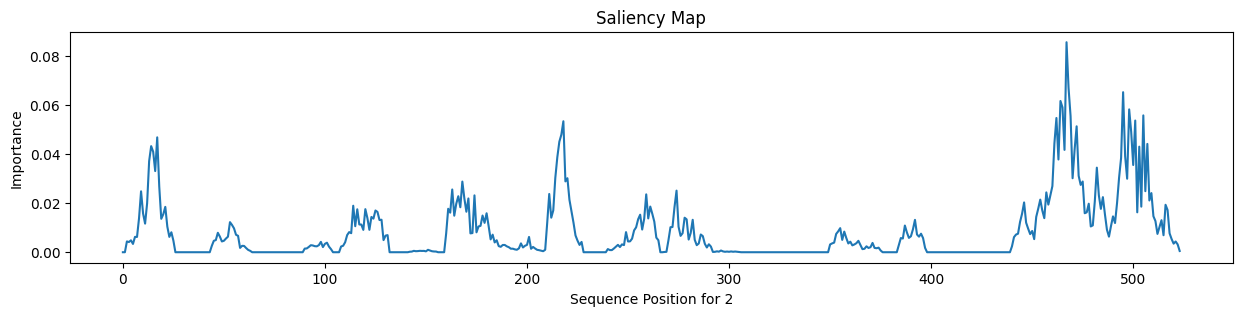

[  9  13  14  15  16  17  18 163 168 214 215 216 217 218 219 220 274 460
 461 462 463 464 465 466 467 468 469 470 471 472 473 474 475 482 493 494
 495 496 497 498 499 500 501 503 505 506 507]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
The predicted host is  2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step


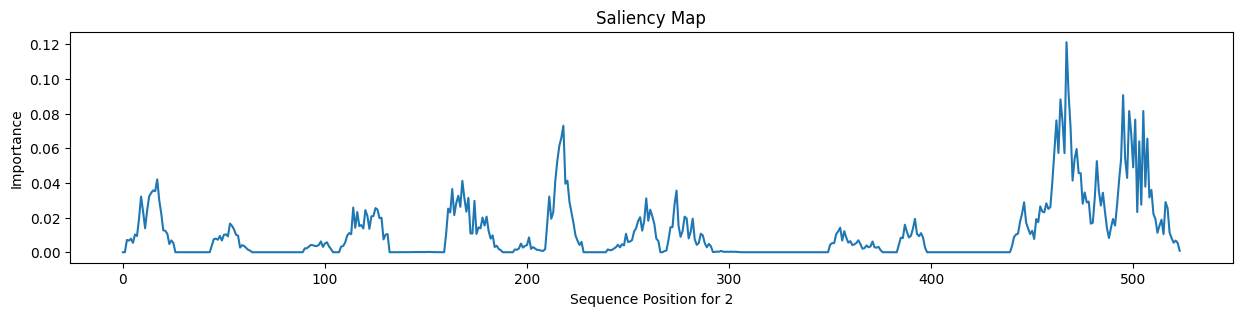

[ 14  15  16  17 163 168 214 215 216 217 218 219 220 274 460 461 462 463
 464 465 466 467 468 469 470 471 472 473 474 476 482 483 485 493 494 495
 496 497 498 499 500 501 503 505 506 507 509]


In [ ]:
df_stattest = pd.read_excel("/content/Stat Testing for Residue Importance in Canis Lupus familiaris.xlsx")

for x in df_stattest["sequence"]:
  saliency_map(x)

Broad patters displayed from saliency maps is that 0-20, residue poisitions has high feature importance. Further, the 450-520 residue positions also have many positions that have high importance. The 160-180 and 255-275 residue positions also consitently shows high feature importance and most of the saliency maps also show high feature importance in the range 210-220. <br>

Regions of moderate fature importance can be seen at the residue positions at 100-120, 50-60, 360-400 ranges however their threshold importance is less than 200% of the peaks, so they are not classifed as peaks and will not be main sources of anlsysis.


##Analysing Residue Importance Across Various Hosts

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
The predicted host is  2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step


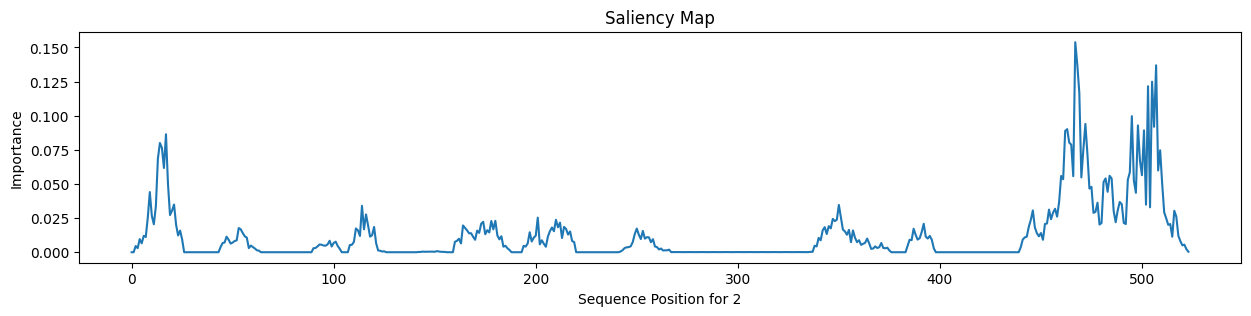

[  9  13  14  15  16  17  18 460 461 462 463 464 465 466 467 468 469 470
 471 472 473 474 475 481 482 483 484 485 493 494 495 496 497 498 499 500
 501 503 505 506 507 508 509 510]


In [ ]:
seq_bostaurus = "MVPQALLFVPLLVFPLCFGKFPIYTIPDKLGPWSPIDIHHLSCPNNLVVEDEGCTNLSGFSYMELKVGYISAIKVNGFTCTGVVTEAETYTNFVGYVTTTFKRKHFRPIPDACRAAYNWKMAGDPRYEESLHNPYPDYHWLRTVKTTKESLVIISPSVADLDPYDKSLHSRVFTSGKCSGITVSSTYCSTNHDYTIWMPENPRLGTSCNIFVNSKGKRASKGGKTCGFVDERGLYKSLKGACKLKLCGVLGLRLMXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXSVRTWNEIIPSKGCLRVGGRCHPHVNGVFFNGIILGPDGHVLIPEMQSSLLQQHMELLESSVIPLMHPLADPSTVFKDGDEAEDFVEVHLPDVHKQVSGVDLGLPNWGKYVLLSAGTLIALMLIIFLMTCCRRVNRPESTQRSLGGTGRKVSVTSQSGKVISSWESYKSGGETRL"
#False
saliency_map(seq_bostaurus)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
The predicted host is  1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


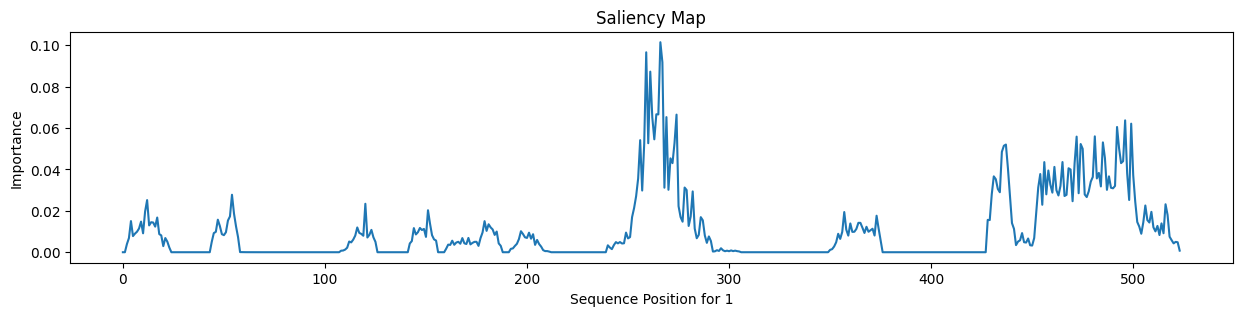

[255 256 258 259 260 261 262 263 264 265 266 267 268 269 271 272 273 274
 278 431 432 435 436 437 438 453 454 456 458 459 461 464 465 468 469 471
 472 474 475 479 480 481 482 483 484 485 486 488 489 491 492 493 494 495
 496 497 499 500]


In [ ]:
seq_canidae = "MVPLVLLFVPLLVFPLCSGKFPIYTIPDKLGPWSPIDIHHLSCPNNLVVEDEGCANLSGFSYMELKVGYISAIKVNGFTCTGVVTEAETYTNFVGYVTTTFRRKHFRPTPDACRAAYNWKMAGDPRYEESLHNPYPDYHWLRTVKTTKESLVIISPSVADLDPYDKSLHSRVFPSGKCSGITVSSTYCSTNHDYTIWMPENLRLGTSCDIFTNSRGKRASKGSKTCGFVDERGLYKSLKGACKLKLCGVLGLRLMDGTWVAMQTSGETKWCPPDQLVNLHDFRSDEIEHLVVEELVKKREECLDALESIMTTKSVSFRRLSHLRKLVPGFGKAYTIFNKTLMEADAHYKSVRTWNEIIPSKGCLRVGGRCHPHVNGVFFNGIILGPDGHVLIPEMQSSLLQQHMELLESSVIPLMHPLADPSTVFKDGDEAEDFVEVHLPDVHKQVSGVDLGLPNWGKYLLLSAGALIALMLMIFLMTCCRKFNRPESTQRSLGGTGRKVSITSQGGKVISSWESYKSGGETRL"
#True
saliency_map(seq_canidae)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
The predicted host is  2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


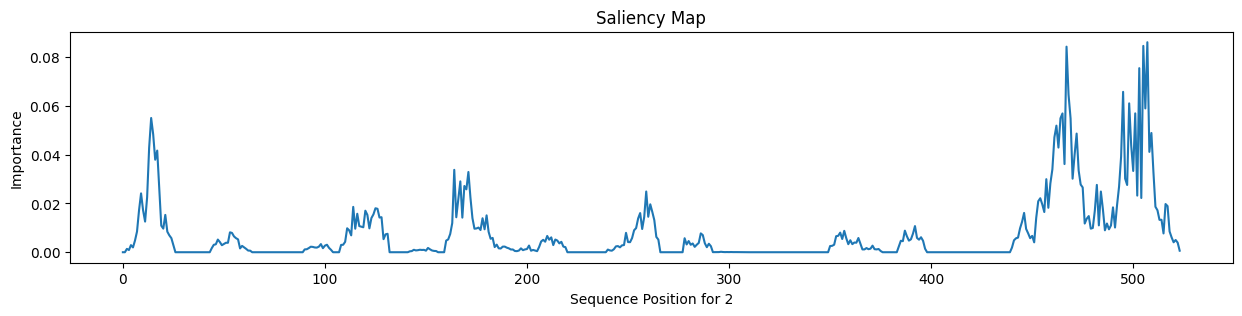

[  9  13  14  15  16  17  18 164 167 169 170 171 259 457 459 460 461 462
 463 464 465 466 467 468 469 470 471 472 473 474 475 482 484 493 494 495
 496 497 498 499 500 501 502 503 505 506 507 508 509 510]


In [ ]:
seq_canisfamiliaris = "MVPQALLFVPLLVFPLCFGKFPIYTIPDKLGPWSPIDIHHLSCPNNLVVEDEGCTNLSGFSYMELKVGYISAIKVNGFTCTGVVTEAETYTNFVGYVTTTFKRKHFRPIPDACRAAYNWKMAGDPRYEESLHNPYPDYHWLRTVKTTKESLVIISPSVADLDPYDKSLHSRVFTSGKCSGITVSSTYCSTNHDYTIWMPENPRLGTSCNIFVNSKGKRASKGGKTCGFVDERGLYKSLKGACKLKLCGVLGLRLMDGTWVAMQTSDETKWCSPDQLVNMHDFRSDEIEHLVVEELVKKREECLDALESIMTTKSVSFRRLSHLRKLVPGFGKAYTIFNKTLMEADAHYKSVRTWNEIIPSKGCLRVGGRCHPHVNGVFFNGIILGPDGHVLIPEMQSSLLQQHMELLESSVIPLMHPLADPSTVFKDGDEAEDFVEVHLPDVHKQVSGVDLGLPNWGKYVLLSAGTLIALMLIIFLMTCCRRVNRPESTQHSLGGTGRKVSVTSQSGKVISSWESYKSGGETRL"
#True
saliency_map(seq_canisfamiliaris)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
The predicted host is  2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step


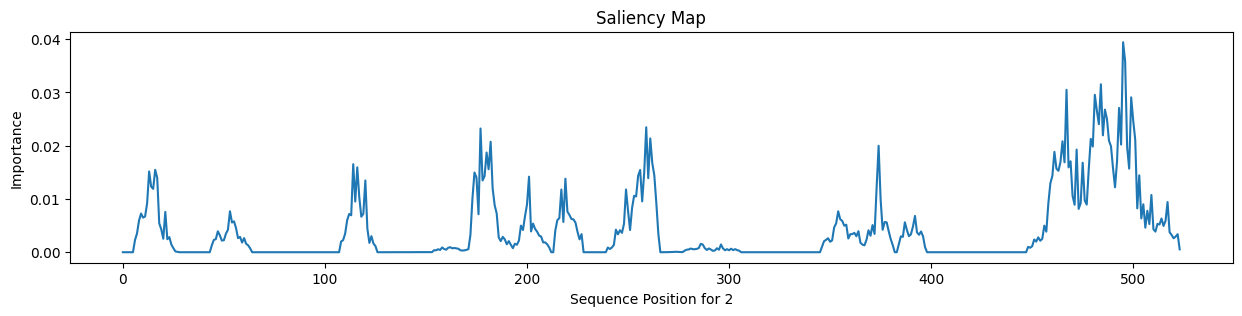

[ 13  16  17 114 116 120 174 175 177 178 179 180 181 182 201 219 255 256
 258 259 260 261 262 263 374 459 460 461 462 463 464 465 466 467 468 469
 472 475 478 479 480 481 482 483 484 485 486 487 488 489 490 492 493 494
 495 496 497 498 499 500 501 503]


In [ ]:
seq_feliscatus = "MVPLALLVVPLLVLSLCSGKFPIYTIPDKLGPWSPIDIHHLSCPNNLVVEDEGCTNLSGFSYMELKVGYISAIKVNGFTCTGVVTEAETYTNFVGYVTTTFRRKHFRPTPDACRAAYNWKMAGDPRYEESLHNPYPDYHWLRTVKTTKESLVIISPSVADLDPYDRSLHSRVFPNGKCSGITVSSTFCPTNHDYTIWMPENPRLGTSCDIFVNSRGKRASKGSKTCGFVDERGLYKSLKGACKLKLCGVLGLRLMDGTWVAMRTSDEAKWCPPDQLVNIHDFRSDEIEHLVVEELVKKREECLDALESIMTTKSVSFRRLSHLRKLVPGFGKAYTIFNKTLMEADAHYKSVRTWDEIIPSKGCLRVGGRCHPHVHGVFFNGIILGPDGHVLIPEMQSSLLQQHMELLESSVIPLMHPLADPSTVFKDGDEAEDFVEVHLPDVHKQISGVDLGLPNWGKYVLMSAGALIALMLIIFLMTCCRKIKRTESTQHSLRGSGRKVSVTSQNGKVISSWESYKSGGETRL"
#False
saliency_map(seq_feliscatus)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
The predicted host is  2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


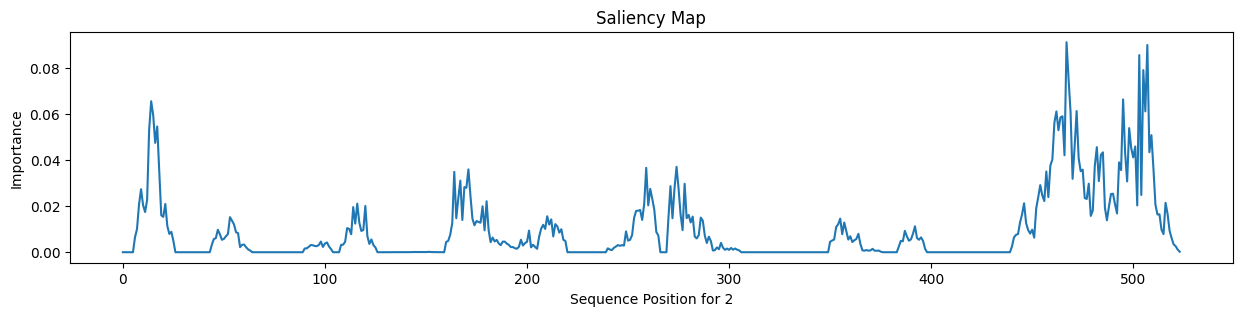

[ 13  14  15  16  17  18 164 167 171 259 271 274 278 454 457 459 460 461
 462 463 464 465 466 467 468 469 470 471 472 473 474 475 478 481 482 483
 484 485 493 494 495 496 497 498 499 500 501 503 505 506 507 508 509 510]


In [ ]:
seq_homosapiens = "MVLQALLFVPLLVFPLCFGKFPIYTIPDKLGPWSPIDIHHLSCPNNLVVEDEGCTNLSGFSYMELKVGYISAIKVNGFTCTGVVTEAETYTNFVGYVTTTFKRKHFRPIPDACRAAYNWKMAGDPRYEESLHNPYPDYHWLRTVKTTKESLVIISPSVADLDPYDKSLHSRVFTSGKCSGITVSSTYCSTNHDYTIWMPENPRLGTSCNIFVNSKGKRASKGGKTCGFVDERGLYKSLKGACKLKLCGVLGLRLXDGTWVAMQTSDETKWCXPDQLVNMHDFRSDEIEHLVVEELVKKREECLDALESIMTTKSVSFRRLSHLRKLVPGFGKAYTIFNXTLMEAXAHYKSVRTWNEIIPSKGCLRVGGRCHPHVNGVFFNGIIXGPDGHVLIPEMQSSLLQQHMELLESSVIPLMHPLADPSTVFKDGDEAEDFVEVHLPDVHKQVSGVDLGLPNWGKYVLLSAGTLIALMLIIFLMTCCRRVNRPESTQRSLGGTGRKVSVTSQSGKVISSWESYKSGGETRX"
#False
saliency_map(seq_homosapiens)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
The predicted host is  6
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


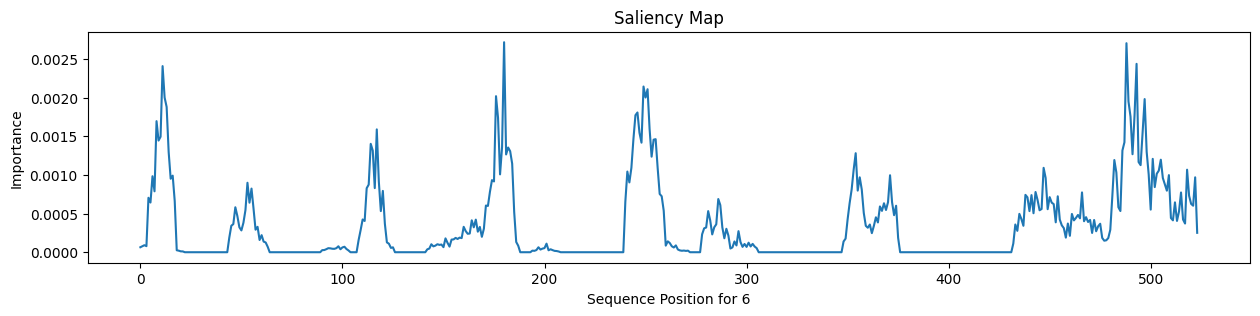

[  8   9  10  11  12  13  14 114 115 117 176 177 179 180 181 182 183 184
 241 243 244 245 246 247 248 249 250 251 252 253 254 255 256 353 354 447
 482 483 486 487 488 489 490 491 492 493 494 495 496 497 498 501 504 505
 518]


In [ ]:
seq_melogale = "MISQAFLFVPLLAFSPCFGKFPIYTIPDKLGPWSPIDIHHLSCPNNLVVEDEGCTNLSGFSYMELKVGYISAIKVNGFTCTGVVTEAETYTNFVGYVTTTFKRKHFRPMPDACRTAYSWKMAGDPRYEESLHNPYPDYHWLRTVKTTKESLVIISPSVADLDPYDKSLHSRVFPGGKCSGLTVSSTCCSTNHDYTIWMPENPRLGTSCDIFTNSRGKRASKGGKTCGFVDERGLYKSLKGACKLKLCGVSGLRLMDGTWVAIQTSDEIKWCSPDQLVNLHDLHSDEIEHLVVEELVKKREECLDALESIMTTKSVSFRRLSHLRKLVPGFGKAYTIFNKTLMEADAHYKSIRTWNEVIPSKGCLRVGGRCHPHVNGVFFNGIILGPDGHVLIPEMQSSLLHQHMELLESSVIPLMHPLADPSTVFKDGDEAEDFVEVHLPDAHKQISGVDLGLPNWGKYVLVSAGALTALMLMIFLMTCCRKTNRAESMPHSPGETGRKVSVTSHNGRVISSWESYKSGGETKL"
#True
saliency_map(seq_melogale)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
The predicted host is  8
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


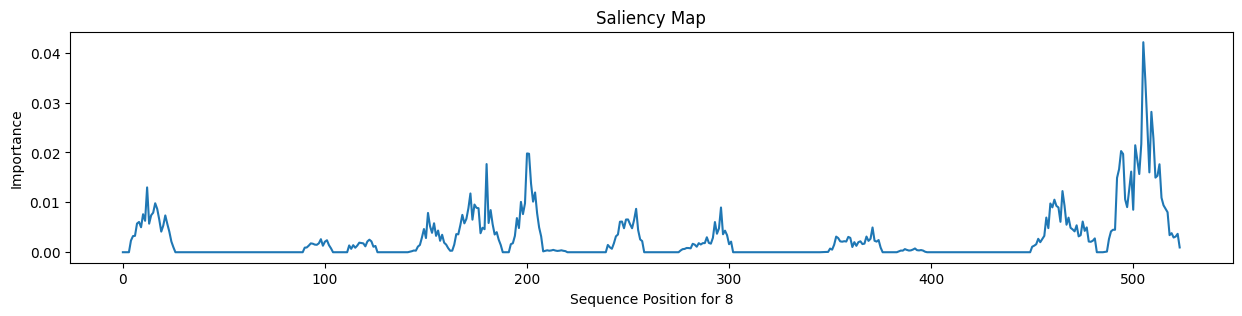

[ 12  15  16  17 171 172 174 175 176 180 182 197 199 200 201 202 203 204
 254 296 459 460 461 462 463 465 466 492 493 494 495 496 497 498 499 500
 501 502 503 504 505 506 507 508 509 510 511 512 513 514 515 516 517]


In [ ]:
seq_mephtidae = "MVPWALLFVPFLISSLCFGKFPIYTIPDKLGPWSPIDIHHLSCPNNLVVEDEGCNSLSGFSYMELKVGYISAIKVNGFTCTGVVTEAETYTNFVGYVTTTFKRKHFRPMPDACRSAYNWKMAGDPRYEESLHNPYPDYHWLRTVKTTKESLIIISPSVADLDPYDKSLHSRIFPGGKCTGLTVSSTYCSTNHDYTIWMPEKAGLGTSCDIFTNSKGKRASKGGKTCGFVDERGLYKSLKGACKLKLCGVSGLRLMDGTWVAIQTLDETKWCSPDQLVNLHDFHSDELEHLVVEELVRKREECLDALESIMTTKSVSFRRLSHLRKLVPGFGKAYTIFNKTLMEADAHYKSVRTWSEIIPSKGCLRVGGRCHPHVNGVFFNGIILGPDGHVLIPEMQSSLLQQHVELLESSVIPLMHPLADPSTVFKDGDEAEDFVEVHLPDVHKQISGVDLGLPSWGKYMLMIAGALTTLMLFIFLMTCCKRVNRTKSIRQGPREIERKVSFTPQNKKVVSSWESYKSGGETKL"
#False
saliency_map(seq_mephtidae)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 272ms/step
The predicted host is  8
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step


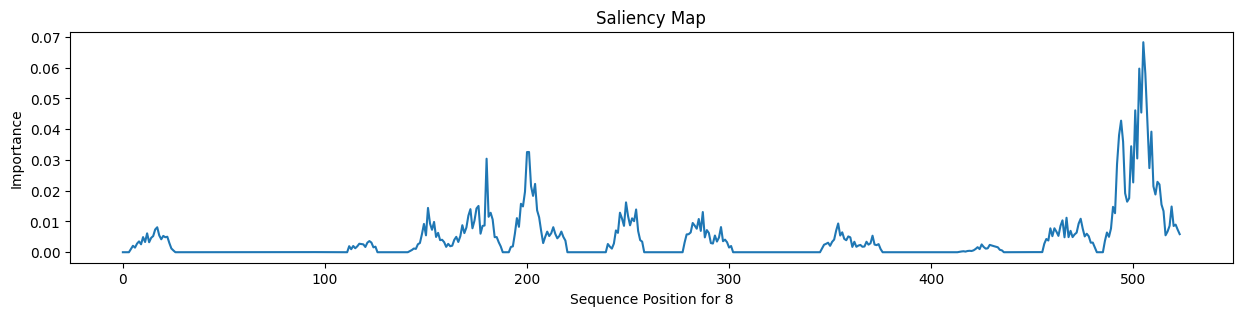

[151 172 175 176 180 182 197 198 199 200 201 202 203 204 205 246 249 254
 287 490 491 492 493 494 495 496 497 498 499 500 501 502 503 504 505 506
 507 508 509 510 511 512 513 514 515 519]


In [ ]:
seq_procyonlotor = 'MVPWAFLFVPFLISSLCFGKFPIYTIPDKLGPWSPIDIHHLSCPNNLVVEDEGCNSLSGFSYMELKVGYISAIKVNGFTCTGVVTEAETYTNFVGYVTTTFKRKHFRPMPDACRSAYNWKMAGDPRYEESLHNPYPDYHWLRTVKTTKESLIIISPSVADLDPYDKSLHSRIFPGGKCTGLTVSSTYCSTNHDYTIWMPEKAGLGTSCDIFTNSKGKRASKGGKTCGFVDERGLYKSLKGACKLKLCGVSGLRLMDGTWVAIQTLDETKWCSPDQLVNLHDFHSDELEHLVVEELVRKREECLDALESIMTTKSVSFRRLSHLRKLVPGFGKAYTIFNKTLMEADAHYKSVRTWSEIIPSKGCLRVGGRCHPHVNGVFFNGIILGPDGHVLIPEMQSSLLQQHVELLESSVIPLMHPLADPSAVFKEGDEAEDFVEVHLPDVHKQISGVDLGLPSWGKYMLMIAGALTTLMLFVFLMTCCKRVNRTKSIRQGPREIERKVSFTPQNKKVISSWESYKSGSETKL'
#True
saliency_map(seq_procyonlotor)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
The predicted host is  9
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


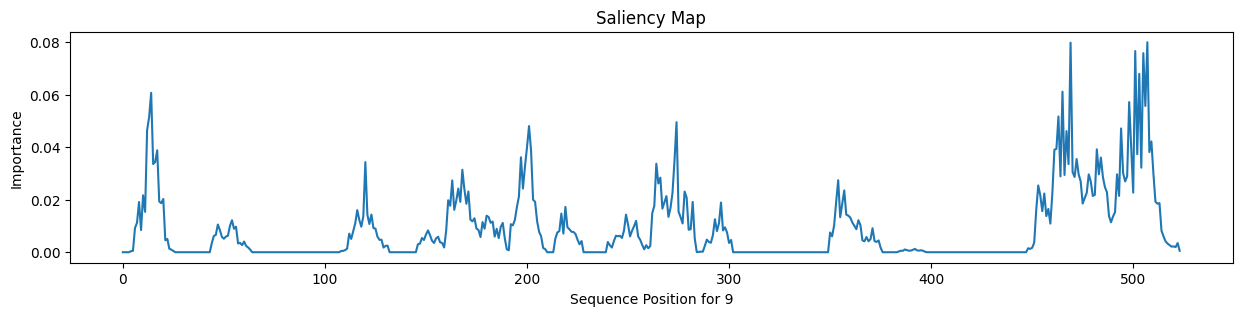

[ 12  13  14  15  16  17 120 163 168 197 199 200 201 202 264 266 273 274
 354 461 462 463 464 465 466 467 468 469 470 471 472 473 478 482 483 484
 485 492 494 495 497 498 499 501 502 503 504 505 506 507 508 509 510]


In [ ]:
seq_vulpes = "MVPQALLFVPLLAFPMCFGKFPIYTIPDKLGPWSPIDIHHLSCPNNLVVEDEGCTNLSGFSYMELKVGYISAIKVNGFTCTGVVTEAETYTNFVGYVTTTFKRKHFRPTPDACRAAYNWKMAGDPRYEESLHNPYPDYHWLRTVKTTKESLIIISPSVADLDPYDKSLHSRVFPSGKCLGITISSTYCSTNHDYTIWMPDNVRLGTSCDIFTNSRGKRASKGSKTCGFVDERGLYKSLKGACKLKLCGVLGLRLMDGTWVAMPTSDETKWCPPDQLVNLHDFRSDEIEHLVVEELVRKREECLDALESIMTTKSVSFRRLSHLRKLVPGFGKAYTIFNKTLMEADAHYKSVRTWNEIIPSKGCLRVGGRCHPHVNGVFFNGIILGPDGHVLIPEMQSSLLQQHMELLESSVIPLMHPLADPSTVFKDGDEAEDFVEVHLPDVHKQISGVDLGLPNWGKYVLIIAGVLIAMILTIFLMTCCGRGNRPKSTQHSLGGIGRKVSSTSQSGKVISSWESYKSGGETRL"
#True
saliency_map(seq_vulpes)

Only consistent feature across all prediction in increased feature importance in the range 460-515.

##Statistical Testing for a randon sample

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/updated_rabies_data.csv")

df_sample = df.sample(500)
df_sample.head()

,id,sequence,Host
708,XLQ28256.1,MIPQALMFAPLLVFSLCFGKFPIYTIPDKLGPWSPIDIHHLSCPNN...,Canis lupus familiaris
3446,QEJ74099.1,MVPWALLFVPFLISSLCFGKFPIYTIPDKLGPWSPIDIHHLSCPNN...,Procyon lotor
2586,QWL76916.1,MVPWALLFVPFLISSLCFGKFPIYTIPDKLGPWSPIDIHHLSCPNN...,Procyon lotor
414,XLQ26786.1,MIPQALLFVPLLVFSLCFGKFPIYTIPDKLGPWSPIDIHHLSCPNN...,Canis lupus familiaris
325,XQO32602.1,MVPQVLLFVPLLVFSMCFGKFPIYTIPDKLGPWSPIDIHHLSCPNN...,Canis lupus familiaris


In [ ]:
def saliency_value(seq):
  input_sample = preprocess_input(seq)

  input_tensor = tf.convert_to_tensor(input_sample, dtype=tf.int32)

  embedding_layer = model.get_layer("embedding")


  embedded_input = embedding_layer(input_tensor)


  with tf.GradientTape() as tape:
      tape.watch(embedded_input)

      x = embedded_input
      for layer in model.layers[model.layers.index(embedding_layer)+1:]:
            x = layer(x)
      predictions = x

      predicted_class = tf.argmax(predictions[0])
      output = predictions[0, predicted_class]

  grads = tape.gradient(output, embedded_input)

  saliency = tf.reduce_max(tf.abs(grads), axis=-1).numpy()[0]
  return saliency

In [ ]:
from collections import defaultdict

def build_saliency_dict(df, saliency_value):
  saliency_dict = defaultdict(list)

  for _, row in df.iterrows():
        host = row["Host"]
        seq = row["sequence"]
        sal = saliency_value(seq)
        saliency_dict[host].append(sal)

  for host in saliency_dict:
        saliency_dict[host] = np.vstack(saliency_dict[host])

  return dict(saliency_dict)

def build_saliency_matrix(df, saliency_value):
    saliency_list = []

    for _, row in df.iterrows():
        seq = row["sequence"]
        sal = saliency_value(seq)
        saliency_list.append(sal)

    saliency_matrix = np.vstack(saliency_list)
    return saliency_matrix

saliency_dict = build_saliency_dict(df_sample, saliency_value)
saliency_matrix = build_saliency_matrix(df_sample, saliency_value)

In [ ]:
def wilcoxon_test_residues(saliency_matrix, n_perm=1000, random_state=42, correction="fdr_bh"):
    from scipy.stats import wilcoxon
    from statsmodels.stats.multitest import multipletests

    np.random.seed(random_state)
    seq_len = saliency_matrix.shape[1]
    results = []

    for pos in range(seq_len):
        observed = saliency_matrix[:, pos]
        permuted = np.array([
            saliency_matrix[np.random.randint(0, saliency_matrix.shape[0]),
                            np.random.randint(0, seq_len)]
            for _ in range(len(observed))
        ])

        try:
            stat, pval = wilcoxon(observed, permuted)
        except ValueError:
            stat, pval = np.nan, 1.0

        results.append((pos, stat, pval))

    df = pd.DataFrame(results, columns=["Position", "W_stat", "p_value"])
    df["p_adj"] = multipletests(df["p_value"], method=correction)[1]
    return df


def wilcoxon_all_hosts(saliency_dict, **kwargs):
    results = {}
    for host, saliency_matrix in saliency_dict.items():
        print(f"Running Wilcoxon for host: {host}, shape={saliency_matrix.shape}")
        results[host] = wilcoxon_test_residues(saliency_matrix, **kwargs)
    return results

In [ ]:
results = wilcoxon_all_hosts(saliency_dict, n_perm=1000)

Running Wilcoxon for host: Canis lupus familiaris, shape=(248, 524)
Running Wilcoxon for host: Procyon lotor, shape=(55, 524)
Running Wilcoxon for host: Mephitidae, shape=(53, 524)
Running Wilcoxon for host: Bos taurus, shape=(44, 524)
Running Wilcoxon for host: Vulpes, shape=(46, 524)
Running Wilcoxon for host: Canidae, shape=(12, 524)
Running Wilcoxon for host: Homo sapiens, shape=(17, 524)
Running Wilcoxon for host: Melogale, shape=(9, 524)
Running Wilcoxon for host: Felis catus, shape=(4, 524)


/usr/local/lib/python3.12/dist-packages/scipy/stats/_wilcoxon.py:178: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se


Running Wilcoxon for host: Eptesicus fuscus, shape=(11, 524)
Running Wilcoxon for host: nan, shape=(1, 524)


/usr/local/lib/python3.12/dist-packages/scipy/stats/_wilcoxon.py:178: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se


In [ ]:
p_adj_df = pd.DataFrame({host: df["p_adj"].values for host, df in results.items()}, index=results[list(results.keys())[0]]["Position"])
display(p_adj_df.head())

,Canis lupus familiaris,Procyon lotor,Mephitidae,Bos taurus,Vulpes,Canidae,Homo sapiens,Melogale,Felis catus,Eptesicus fuscus,NaN
Position,,,,,,,,,,,
0,3.730628e-21,0.000014,0.000012,0.000136,0.000028,0.139077,0.019696,0.619595,0.766082,0.238182,1.0
1,4.843628e-15,0.000002,0.000022,0.000060,0.000022,0.036881,0.019922,0.226174,0.555085,0.068803,1.0
2,4.977047e-03,0.000028,0.000100,0.363655,0.000011,0.905389,0.119638,0.429307,1.000000,0.507752,1.0
3,8.717746e-01,0.000077,0.000316,0.113110,0.000016,0.231099,0.019922,0.988710,0.555085,0.203838,1.0
4,1.498427e-01,0.348616,0.468352,0.528618,0.025973,0.307884,0.710155,1.000000,0.555085,0.778986,1.0


In [ ]:
p_adj_df.to_csv("p_adj_df.csv")

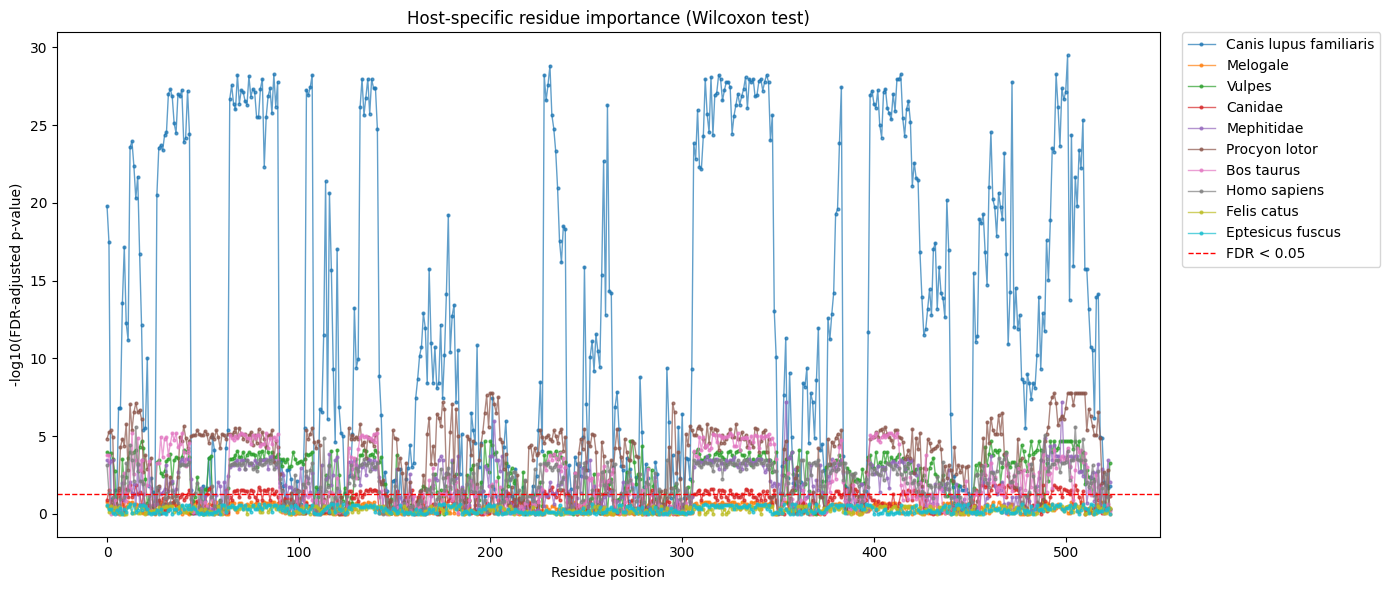

In [ ]:
plt.figure(figsize=(14, 6))

for host, df in results.items():
    y = -np.log10(df["p_adj"].replace(0, 1e-300))
    x = df["Position"]
    plt.plot(x, y, marker="o", markersize=2, linewidth=1, label=host, alpha=0.7)

thresh = -np.log10(0.05)
plt.axhline(y=thresh, color="red", linestyle="--", linewidth=1, label="FDR < 0.05")

plt.xlabel("Residue position")
plt.ylabel("-log10(FDR-adjusted p-value)")
plt.title("Host-specific residue importance (Wilcoxon test)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
plt.tight_layout()
plt.show()

In [ ]:
def permutation_test_region(saliency_matrix, region, n_perm=1000, random_state=42):
    np.random.seed(random_state)
    seq_len = saliency_matrix.shape[1]
    region_importance = saliency_matrix[:, region[0]:region[1]+1].mean()

    perm_means = []
    for _ in range(n_perm):
        rand_start = np.random.randint(0, seq_len - (region[1]-region[0]))
        rand_end = rand_start + (region[1]-region[0])
        perm_means.append(saliency_matrix[:, rand_start:rand_end].mean())

    p_value = (np.sum(np.array(perm_means) >= region_importance) + 1) / (n_perm + 1)
    return region_importance, np.mean(perm_means), p_value

permutation_test_region(saliency_matrix, (460,520), n_perm=1000)

(np.float32(0.013944366),
 np.float32(0.0039320155),
 np.float64(0.028971028971028972))

The result of the test is that the region 460-520 is statsitically signficant across all hosts and that residue wise importance varies on average across graps as demonstrated by the manhattan plot.